# **Day 47: Hierarchical Clustering, DBSCAN, HDBSCAN and Spectral Clustering**
*Module 8 - Unsupervised Learning*

K-Means needs K and assumes round clusters. Today's methods relax these assumptions:
- **Hierarchical (agglomerative) clustering** builds a whole tree of clusterings (a dendrogram).
- **DBSCAN / HDBSCAN** find clusters of **arbitrary shape** as dense regions and label sparse points as **noise**.
- **Spectral clustering** uses a similarity graph to separate non-convex clusters.

> Hierarchical clustering builds a tree of nested groups. DBSCAN and HDBSCAN find clusters of any shape as dense regions and label isolated points as noise. Spectral clustering uses graph connections.
>
> *Example:* DBSCAN can find irregular clusters of fire hotspots along a ridge and ignore scattered single detections as noise.

In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore", message="Graph is not fully connected")   # the k-NN graph of two separate clusters is disconnected by design
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, DBSCAN, HDBSCAN, SpectralClustering, KMeans
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
rng = np.random.default_rng(47)

## **1. Agglomerative Clustering**
Start with every point as its own cluster; repeatedly **merge the two closest clusters**. "Closest" depends on the **linkage**:

| Linkage | Distance between clusters | Behaviour |
|---|---|---|
| Single | closest pair of points | Finds elongated chains; sensitive to noise ("chaining") |
| Complete | farthest pair | Compact clusters of similar diameter |
| Average | mean of all pairwise distances | Compromise |
| **Ward** | increase in within-cluster variance | Compact, K-Means-like; most used |

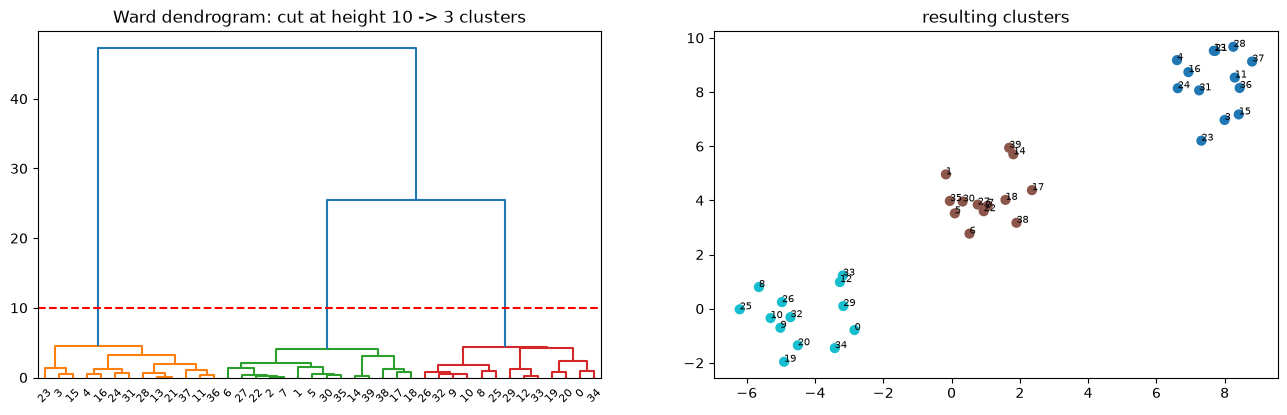

In [2]:
X, y = make_blobs(40, centers=3, cluster_std=0.9, random_state=3)
Z = linkage(X, method="ward")
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
dendrogram(Z, ax=axes[0], color_threshold=10); axes[0].axhline(10, c="r", ls="--"); axes[0].set_title("Ward dendrogram: cut at height 10 -> 3 clusters")
axes[1].scatter(*X.T, c=fcluster(Z, t=10, criterion="distance"), cmap="tab10", s=40)
for i, p in enumerate(X): axes[1].annotate(str(i), p, fontsize=7)
axes[1].set_title("resulting clusters"); plt.show()

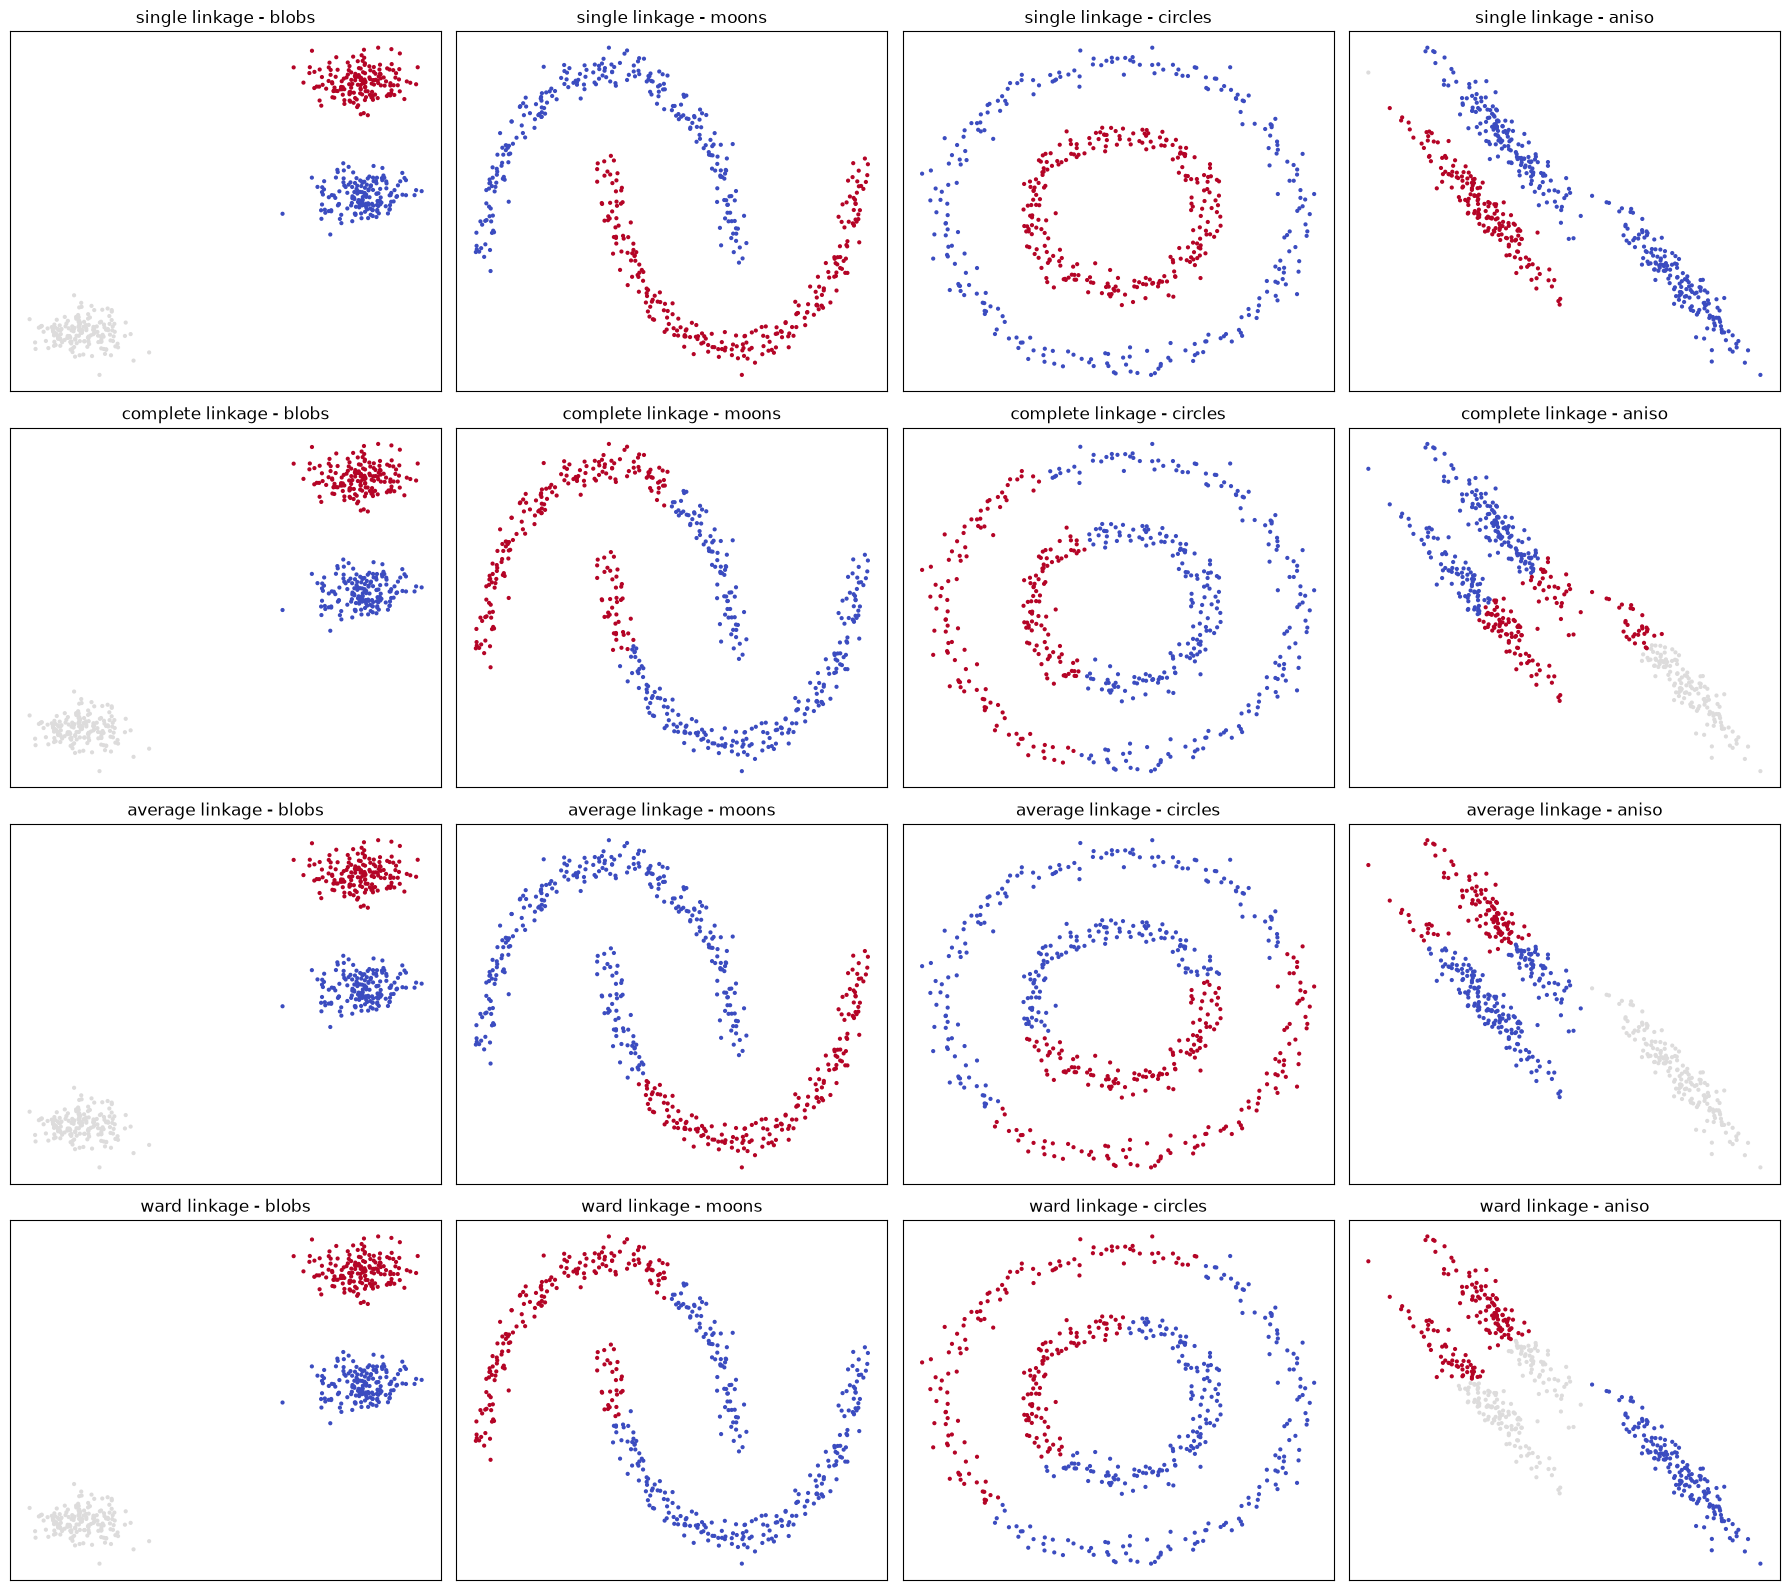

In [3]:
datasets = {"blobs": make_blobs(500, centers=3, random_state=8)[0], "moons": make_moons(500, noise=0.05, random_state=0)[0],
            "circles": make_circles(500, noise=0.05, factor=0.5, random_state=0)[0],
            "aniso": make_blobs(500, centers=3, random_state=170)[0] @ np.array([[0.6, -0.6], [-0.4, 0.8]])}
k_of = {"blobs": 3, "moons": 2, "circles": 2, "aniso": 3}
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
for r, link in enumerate(["single", "complete", "average", "ward"]):
    for c, (name, D) in enumerate(datasets.items()):
        lab = AgglomerativeClustering(n_clusters=k_of[name], linkage=link).fit_predict(D)
        axes[r, c].scatter(*D.T, c=lab, s=4, cmap="coolwarm"); axes[r, c].set_title(f"{link} linkage - {name}")
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
plt.tight_layout(); plt.show()

Single linkage follows the moons and circles (chaining) but would be ruined by a few noise points bridging clusters; Ward behaves like K-Means.

## **2. Connectivity Constraints: Spatially Contiguous Regions**
In geography we often want clusters that are **contiguous** in space (regionalisation: management zones in a field, ecoregions). Give agglomerative clustering a connectivity graph so that only neighbouring units can merge.

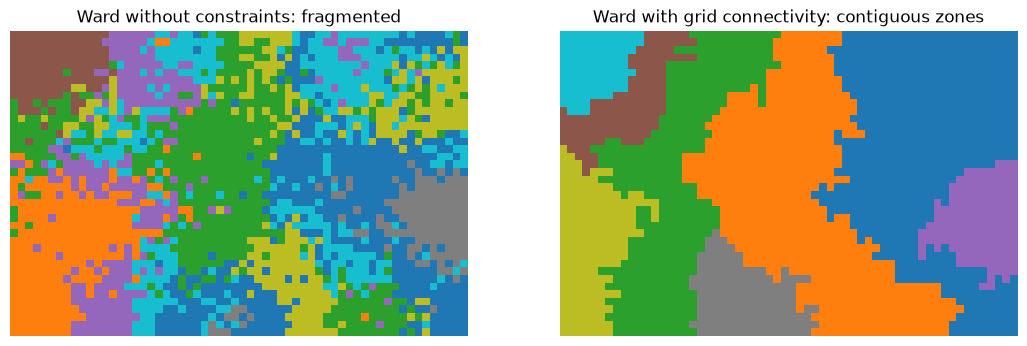

In [4]:
from sklearn.feature_extraction.image import grid_to_graph
from scipy.ndimage import gaussian_filter
H, W = 40, 60
attr = np.stack([gaussian_filter(rng.normal(size=(H, W)), 5) for _ in range(3)], -1)
attr = (attr - attr.mean((0, 1))) / attr.std((0, 1)) + rng.normal(0, 0.4, (H, W, 3))
pix = attr.reshape(-1, 3)
conn = grid_to_graph(H, W)
lab_free = AgglomerativeClustering(8, linkage="ward").fit_predict(pix).reshape(H, W)
lab_conn = AgglomerativeClustering(8, linkage="ward", connectivity=conn).fit_predict(pix).reshape(H, W)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].imshow(lab_free, cmap="tab10"); axes[0].set_title("Ward without constraints: fragmented")
axes[1].imshow(lab_conn, cmap="tab10"); axes[1].set_title("Ward with grid connectivity: contiguous zones")
for ax in axes: ax.axis("off")
plt.show()

## **3. DBSCAN: Density-Based Clustering**
Two parameters: radius `eps` and `min_samples`.
- **Core point**: at least `min_samples` neighbours within `eps`.
- **Border point**: within `eps` of a core point, but not core itself.
- **Noise**: neither (label -1).
Clusters = connected groups of core points (plus their borders). No K needed; any shape; outliers detected.

### Choosing eps: the k-distance plot
Sort every point's distance to its k-th nearest neighbour (k = min_samples). The "knee" is a good eps.

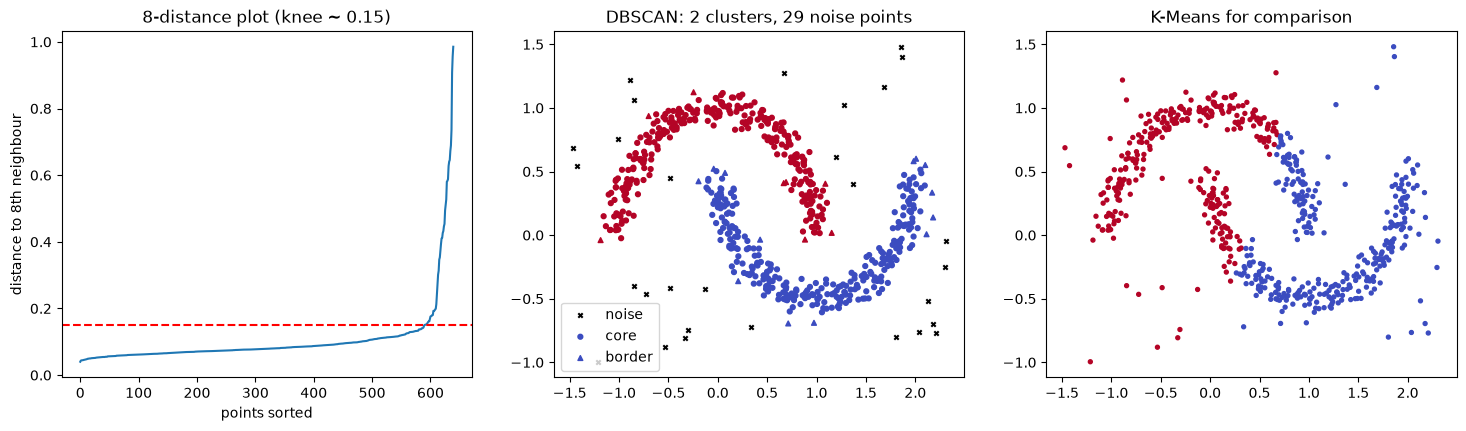

In [5]:
Xm, ym = make_moons(600, noise=0.07, random_state=1)
Xm = np.vstack([Xm, rng.uniform([-1.5, -1], [2.5, 1.5], (40, 2))])                 # add background noise
k = 8
dists = np.sort(NearestNeighbors(n_neighbors=k).fit(Xm).kneighbors(Xm)[0][:, -1])
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].plot(dists); axes[0].axhline(0.15, c="r", ls="--"); axes[0].set(title=f"{k}-distance plot (knee ~ 0.15)", xlabel="points sorted", ylabel=f"distance to {k}th neighbour")
db = DBSCAN(eps=0.15, min_samples=k).fit(Xm)
core = np.zeros(len(Xm), bool); core[db.core_sample_indices_] = True
axes[1].scatter(*Xm[db.labels_ == -1].T, c="k", s=10, marker="x", label="noise")
axes[1].scatter(*Xm[core].T, c=db.labels_[core], cmap="coolwarm", s=12, label="core")
axes[1].scatter(*Xm[~core & (db.labels_ != -1)].T, c=db.labels_[~core & (db.labels_ != -1)], cmap="coolwarm", s=12, marker="^", label="border")
axes[1].legend(); axes[1].set_title(f"DBSCAN: {len(set(db.labels_)) - 1} clusters, {np.sum(db.labels_ == -1)} noise points")
axes[2].scatter(*Xm.T, c=KMeans(2, n_init=10, random_state=0).fit_predict(Xm), cmap="coolwarm", s=8); axes[2].set_title("K-Means for comparison")
plt.show()

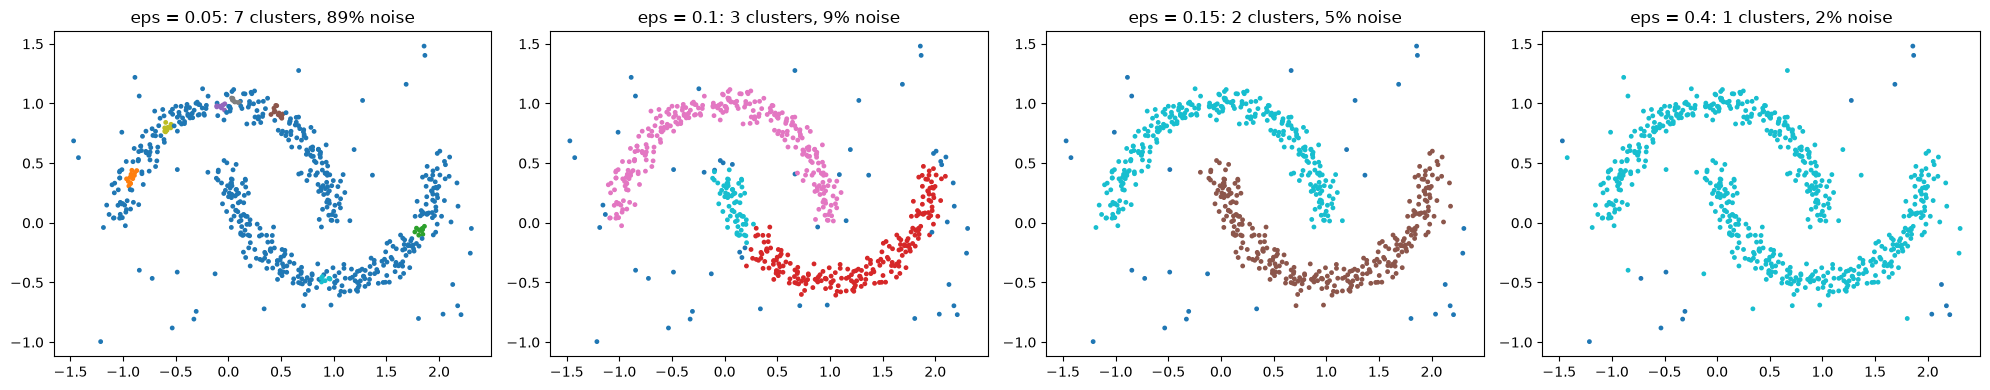

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, eps in zip(axes, [0.05, 0.1, 0.15, 0.4]):
    lab = DBSCAN(eps=eps, min_samples=k).fit_predict(Xm)
    ax.scatter(*Xm.T, c=lab, cmap="tab10", s=6); ax.set_title(f"eps = {eps}: {len(set(lab) - {-1})} clusters, {np.mean(lab == -1):.0%} noise")
plt.tight_layout(); plt.show()

## **4. HDBSCAN: Varying Densities**
DBSCAN uses one global density threshold, so it fails when clusters have **different densities**. **HDBSCAN** (Campello et al., 2013) builds a hierarchy over all density levels and keeps the most **stable** clusters. Main parameter: `min_cluster_size`. Also gives membership probabilities.

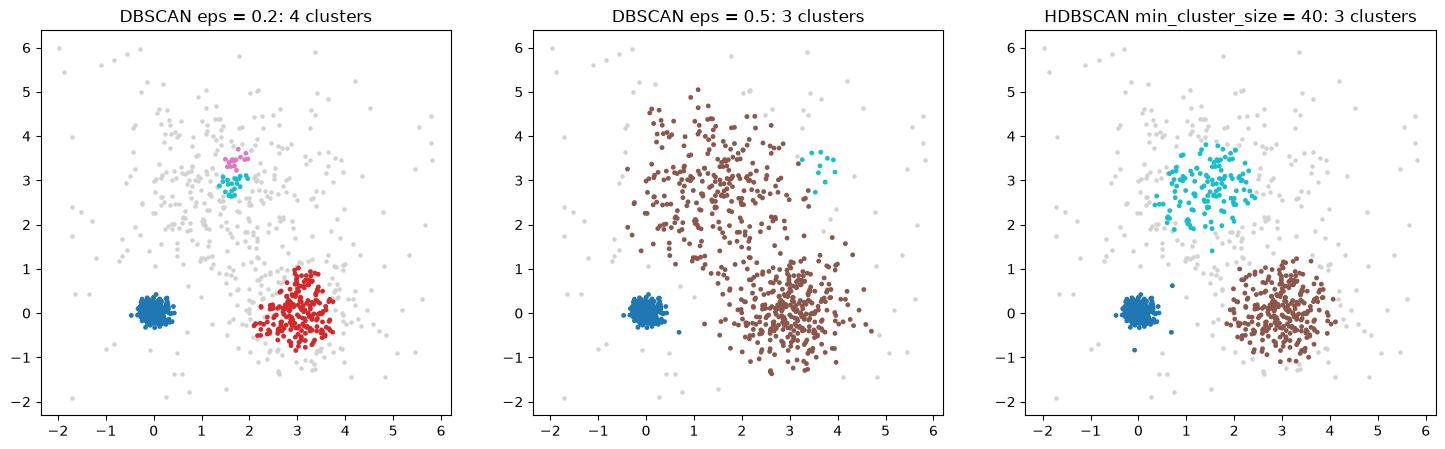

In [7]:
Xv = np.vstack([rng.normal([0, 0], 0.15, (300, 2)), rng.normal([3, 0], 0.6, (300, 2)), rng.normal([1.5, 3], 1.0, (300, 2)),
                rng.uniform([-2, -2], [6, 6], (80, 2))])
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, [("DBSCAN eps = 0.2", DBSCAN(eps=0.2, min_samples=10)), ("DBSCAN eps = 0.5", DBSCAN(eps=0.5, min_samples=10)),
                                    ("HDBSCAN min_cluster_size = 40", HDBSCAN(min_cluster_size=40, copy=True))]):
    lab = model.fit_predict(Xv)
    ax.scatter(*Xv[lab == -1].T, c="lightgrey", s=5); ax.scatter(*Xv[lab != -1].T, c=lab[lab != -1], cmap="tab10", s=6)
    ax.set_title(f"{name}: {len(set(lab) - {-1})} clusters")
plt.show()

## **5. Spectral Clustering**
Build a similarity graph (e.g. k-nearest neighbours), compute the eigenvectors of its **graph Laplacian**, and run K-Means in that eigenvector space. Points connected by paths of similar neighbours end up together, even in non-convex shapes.

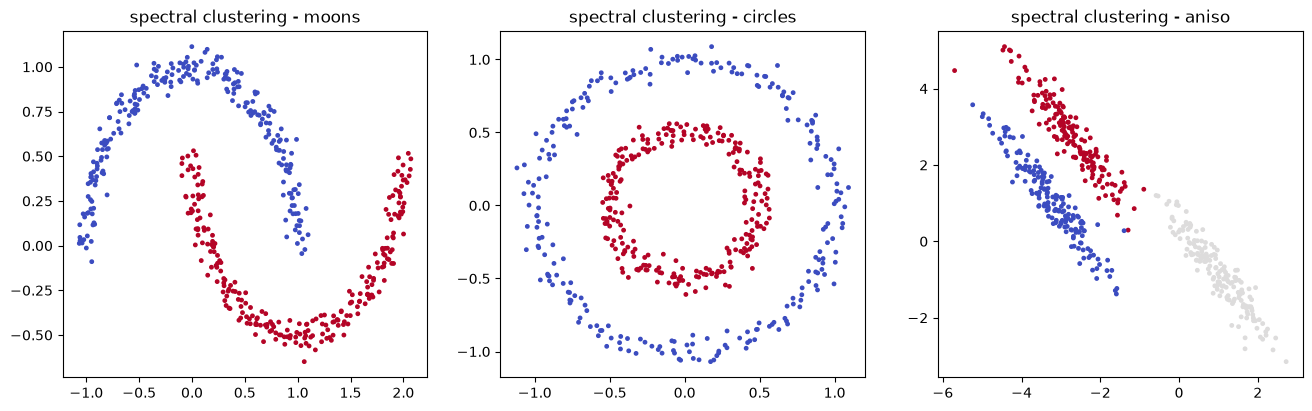

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, D, kk) in zip(axes, [("moons", datasets["moons"], 2), ("circles", datasets["circles"], 2), ("aniso", datasets["aniso"], 3)]):
    lab = SpectralClustering(kk, affinity="nearest_neighbors", n_neighbors=15, random_state=0).fit_predict(D)
    ax.scatter(*D.T, c=lab, cmap="coolwarm", s=6); ax.set_title(f"spectral clustering - {name}")
plt.show()

# **Part 2: Going Deeper**

### Spatial hotspots of events
Point events (landslide scars, disease cases, crimes, fire detections) cluster in space. DBSCAN/HDBSCAN on coordinates finds hotspots and labels isolated events as noise. For geographic coordinates use the **haversine** metric (radians; eps in radians = km / 6371).

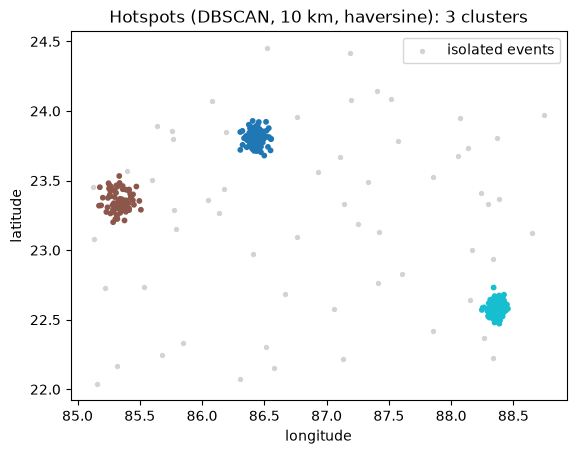

In [9]:
centres = np.array([[23.80, 86.43], [23.35, 85.33], [22.57, 88.36]])            # Dhanbad, Ranchi, Kolkata
events = np.vstack([c + rng.normal(0, s, (n_, 2)) for c, s, n_ in zip(centres, [0.05, 0.08, 0.04], [120, 80, 150])])
events = np.vstack([events, rng.uniform([22, 85], [24.5, 88.8], (60, 2))])
db_geo = DBSCAN(eps=10 / 6371, min_samples=15, metric="haversine").fit(np.radians(events))   # 10 km radius
lab = db_geo.labels_
plt.scatter(events[lab == -1, 1], events[lab == -1, 0], c="lightgrey", s=8, label="isolated events")
plt.scatter(events[lab != -1, 1], events[lab != -1, 0], c=lab[lab != -1], cmap="tab10", s=10)
plt.xlabel("longitude"); plt.ylabel("latitude"); plt.title(f"Hotspots (DBSCAN, 10 km, haversine): {len(set(lab) - {-1})} clusters"); plt.legend(); plt.show()

### Choosing an algorithm

| Situation | Good choice |
|---|---|
| Round clusters, large data, known K | K-Means / MiniBatch K-Means |
| Need a hierarchy or contiguous regions | Agglomerative (Ward) + connectivity |
| Arbitrary shapes + noise, similar densities | DBSCAN |
| Arbitrary shapes, varying densities | HDBSCAN |
| Non-convex, moderate size, known K | Spectral clustering |
| Elliptical clusters, soft membership | Gaussian mixture (Day 48) |

## **Practice Problems**
1. Cut the Ward dendrogram of the 40-point dataset into 2, 3 and 4 clusters and compute the silhouette for each.
2. Make DBSCAN work on `datasets["circles"]` (find eps with the k-distance plot).
3. Compare ARI of K-Means, Ward, DBSCAN, HDBSCAN and spectral clustering on the moons dataset.
4. *(Advanced)* Run HDBSCAN on the event coordinates (haversine) and compare the number of hotspots with DBSCAN.

In [10]:
# Solution 1
from sklearn.metrics import silhouette_score
for kk in [2, 3, 4]:
    print(f"K = {kk}: silhouette {silhouette_score(X, fcluster(Z, kk, criterion='maxclust')):.3f}")
# Solution 2
Dc = datasets["circles"]
lab_c = DBSCAN(eps=0.15, min_samples=5).fit_predict(Dc); print("circles DBSCAN clusters:", len(set(lab_c) - {-1}))
# Solution 3
Dm, ym2 = make_moons(500, noise=0.05, random_state=0)
for name, m in [("K-Means", KMeans(2, n_init=10, random_state=0)), ("Ward", AgglomerativeClustering(2)), ("DBSCAN", DBSCAN(eps=0.2, min_samples=5)),
                ("HDBSCAN", HDBSCAN(min_cluster_size=20, copy=True)), ("Spectral", SpectralClustering(2, affinity="nearest_neighbors", random_state=0))]:
    print(f"{name:<9} ARI {adjusted_rand_score(ym2, m.fit_predict(Dm)):.3f}")
# Solution 4
lab_h = HDBSCAN(min_cluster_size=30, metric="haversine", copy=True).fit_predict(np.radians(events))
print("HDBSCAN hotspots:", len(set(lab_h) - {-1}), "| noise share:", round(np.mean(lab_h == -1), 3))

K = 2: silhouette 0.660
K = 3: silhouette 0.761
K = 4: silhouette 0.642
circles DBSCAN clusters: 2
K-Means   ARI 0.257
Ward      ARI 0.299
DBSCAN    ARI 1.000
HDBSCAN   ARI 1.000
Spectral  ARI 1.000
HDBSCAN hotspots: 3 | noise share: 0.098


## **Key References**
- Ward, J. H. (1963). Hierarchical grouping to optimize an objective function. *Journal of the American Statistical Association*, 58(301), 236-244.
- Ester, M., Kriegel, H.-P., Sander, J., & Xu, X. (1996). A density-based algorithm for discovering clusters in large spatial databases with noise. *KDD-96*, 226-231.
- Campello, R. J. G. B., Moulavi, D., & Sander, J. (2013). Density-based clustering based on hierarchical density estimates. *PAKDD 2013*, 160-172.
- McInnes, L., Healy, J., & Astels, S. (2017). hdbscan: Hierarchical density based clustering. *Journal of Open Source Software*, 2(11), 205.
- von Luxburg, U. (2007). A tutorial on spectral clustering. *Statistics and Computing*, 17(4), 395-416.
- Ng, A. Y., Jordan, M. I., & Weiss, Y. (2002). On spectral clustering: Analysis and an algorithm. *NeurIPS 14*.